# **Extended Data Figure 2**
Reproduces Extended Data Figure 2 from simulation data. Data used:
- `DNg100_Stim/hyak/run_id=32166681` (**a**,**b**)
- `DNg100_Stim/hyak/run_id=32170869` (**b**)
- `DNg100_Stim/hyak/run_id=32172781` (**b**)
- `DNg100_Stim/hyak/run_id=32176187` (**b**)
- `DNg100_Stim/hyak/run_id=32181297` (**b**)
- `DN_Screen/hyak/run_id=32753379` (**c**)
- `DNg100_Stim/hyak/run_id=32928093` (**d**)

*$b$ parameter grid*:
- `DNg100_Stim/hyak/run_id=33258130` (**e**)
- `DNg100_Stim/hyak/run_id=34251325` (**e**)
- `DNg100_Stim/hyak/run_id=34280323` (**e**)
- `DNg100_Stim/hyak/run_id=34280329` (**e**)
- `DNg100_Stim/hyak/run_id=34280336` (**e**)
- `DNg100_Stim/hyak/run_id=34280337` (**e**)
- `DNg100_Stim/hyak/run_id=34280345` (**e**)
- `DNg100_Stim/default/run_id=hyak-33258130_finalRerun_20260402` (**e**)

In [ ]:
dataPath = "/data/users/smpuglie/published-simulations/"

In [ ]:
## imports
import matplotlib.pyplot as plt
from src.utils.plot_utils import *
from src.utils.sim_utils import *
import yaml
import numpy as np
import jax.numpy as jnp
import sparse
from hydra import initialize, compose
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
from pathlib import Path, PosixPath
import h5py
from tqdm import tqdm

os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Specify GPU to use

# # PLOT defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["xtick.minor.size"] = 1.0
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["xtick.minor.width"] = 0.18
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=TITLE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"

lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"
lightInhColor = "#00acd6"
connColormap = sns.blend_palette([inhColor,lightInhColor,"white",lightExcColor,excColor],as_cmap=True)

Using diffeqsolve-based neural simulation (original)


# DNg100 activation with 3x standard deviations of biophysical parameters

## for all parameters

In [2]:
simType = "DNg100_Stim"
simPath = simType+"/hyak/run_id=32166681"
folder = dataPath + simPath
# keep this sparse: .todense() on all 1024 sims allocates ~38 GB on top of the
# coords and gets the kernel OOM-killed, so densify one sim at a time below
Rs = load_Rs_npz(folder+f"/ckpt/{simType}_Rs.npz")
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
nSims = Rs.shape[1]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive = pd.Series(index=np.arange(nSims))
nMnsActivePastTransient = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[dataset,i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    nMnsActivePastTransient.loc[i] = np.sum(activeMnsMaskPastTransient)
    simScore.loc[i] = score

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


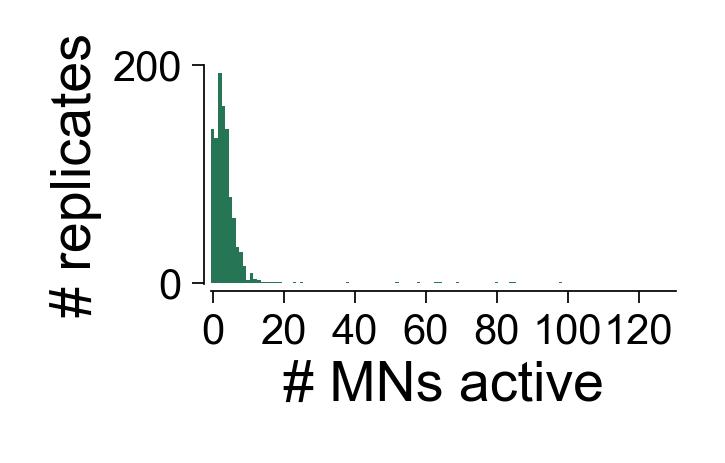

In [3]:
plt.figure(figsize=(1.200,0.57))

ax = sns.histplot(nMnsActive,color=mnColor,edgecolor="none",binwidth=1,kde=False,alpha=1,discrete=True)

plt.ylim([-1,200])
plt.xticks(np.arange(0,130,20))
plt.xlim([-0.5,130.5])
plt.ylabel("# replicates",fontsize=8)
plt.xlabel("# MNs active",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
sns.despine(offset=1)
plt.gcf().set_dpi(500)


# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnHistZoomedOut_2.svg",transparent=True)
plt.show()

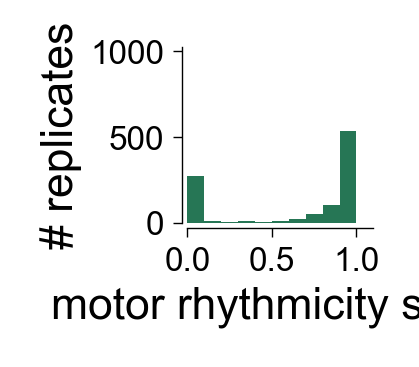

In [4]:
plt.figure(figsize=(0.600,0.57))

ax = sns.histplot(simScore,color=mnColor,edgecolor="none",bins=np.arange(0,1.5,0.10000001),kde=False,alpha=1.0)
plt.xlim([0,1.1])
plt.ylim([0,1024])
plt.yticks([0,500,1000])
plt.xticks(np.arange(0,1.1,0.5))
plt.xlabel("motor rhythmicity score",fontsize=8)
plt.ylabel("# replicates",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)

sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreHist.svg",transparent=True)
plt.show()

## for all but one parameter

### load the first time

In [2]:
runIdToParamDict = {
    "32166681": "none",
    "32170869": "gain",
    "32172781": "threshold",
    "32176187": "time constant",
    "32181297": "max rate"
}

In [ ]:
simType = "DNg100_Stim"
nMnsActiveDict = dict.fromkeys(runIdToParamDict.values(),[])
simScoreDict = dict.fromkeys(runIdToParamDict.values(),[])

runIds = list(runIdToParamDict.keys())

for runId in runIds:
    simPath = simType+f"/hyak/run_id={runId}"
    print(f"Loading {simPath}...")
    folder = dataPath + simPath
    # start some placeholders
    params = DictConfig(load_from_yaml(folder+f"/logs/run_config.yaml"))
    wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
    mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])


    params = DictConfig(load_from_yaml(folder+f"/logs/run_config.yaml"))
    restoredParamName = runIdToParamDict[runId]
    seed = params.experiment.seed

    # kept sparse, densified one sim at a time -- see the note in the cell above
    Rs = load_Rs_npz(folder+f"/ckpt/{simType}_Rs.npz")
    nSims = Rs.shape[1]

    nMnsActive = pd.Series(index=np.arange(nSims))
    simScore = pd.Series(index=np.arange(nSims))

    for i in range(nSims):
        R = Rs[0,i].todense()

        activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        nMnsActive.loc[i] = np.sum(activeMnsMask)
        activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
        simScore.loc[i] = score

    nMnsActiveDict[restoredParamName] = nMnsActiveDict[restoredParamName] + nMnsActive.tolist()
    simScoreDict[restoredParamName] = simScoreDict[restoredParamName] + simScore.tolist()

In [ ]:
nMnsActive_combined = pd.DataFrame.from_dict(nMnsActiveDict)
simScore_combined = pd.DataFrame.from_dict(simScoreDict)

figFolder = "../figures/"
figFolder += f"{simType}-3xStdDevs-combined"
if not os.path.exists(figFolder):
    os.makedirs(figFolder)
# nMnsActive_combined.to_csv(figFolder+"/nMnsActive.csv")
# simScore_combined.to_csv(figFolder+"/scores.csv")

### reload and plot

In [2]:
figFolder = "../figures/"
figFolder += f"DNg100_Stim-3xStdDevs-combined"

nMnsActive_combined = pd.read_csv(figFolder+"/nMnsActive.csv",index_col=0)
simScore_combined = pd.read_csv(figFolder+"/scores.csv",index_col=0)

In [3]:
from seaborn.external import husl
def make_palette(color):
    hue = husl.hex_to_husl(color)[0]
    return sns.blend_palette(["white",husl.husl_to_rgb(hue,45,80),color,husl.husl_to_rgb(hue,65,35)],as_cmap=True)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


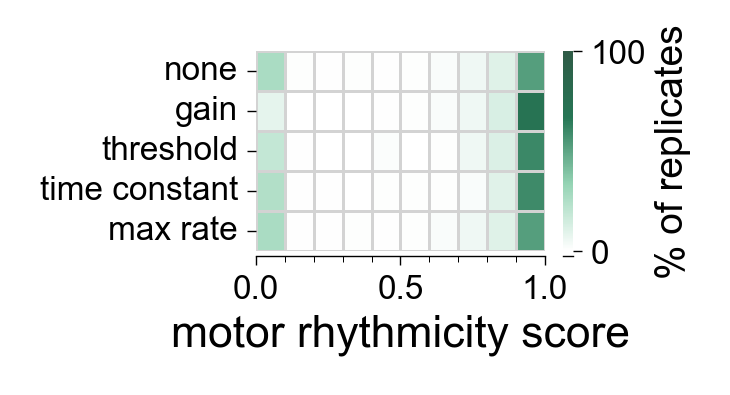

In [4]:
nSims = len(simScore_combined)
histBins = np.linspace(0,np.max(simScore_combined),11)
print(histBins)
histBinCenters = (histBins[:-1] + histBins[1:]) / 2
scoreHistDf = pd.DataFrame(index=histBinCenters,columns = simScore_combined.columns)
for col in simScore_combined.columns:
    scoreHistDf[col] = 100*(np.histogram(simScore_combined[col],bins=histBins)[0] / nSims)

xmax = 1.05
nBinsPlotted = len(scoreHistDf[:xmax])
xticklabels = np.round(histBins[np.arange(0,nBinsPlotted+1)],1).astype(str).tolist()
for i in range(len(xticklabels)):
    if i % 5 !=0:
        xticklabels[i]=""

plt.figure(figsize=(1.1647,0.648))

ax = sns.heatmap(scoreHistDf[:xmax].transpose(),cmap=make_palette(mnColor),cbar=True,vmin=0,vmax=100,yticklabels=True,cbar_kws={"ticks":[0,100]},linecolor="lightgray",linewidths=0.5)
cbar = ax.collections[0].colorbar
cbar.set_label("% of replicates",fontsize=7)
sns.despine(offset={"left":2,"bottom":1},left=True)

ax.set_xticks(np.arange(0,nBinsPlotted+1,5),np.round(histBins[np.arange(0,nBinsPlotted+1,5)],1))
ax.set_xticks(np.arange(0,nBinsPlotted+1),minor=True)
# ax.grid()
plt.gcf().set_dpi(400)
plt.xlabel("motor rhythmicity score")

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreStackedHeatmaps.svg",transparent=True)
plt.show()

/tmp/ipykernel_76263/2106817023.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  scoreHistDf.fillna(0,inplace=True)


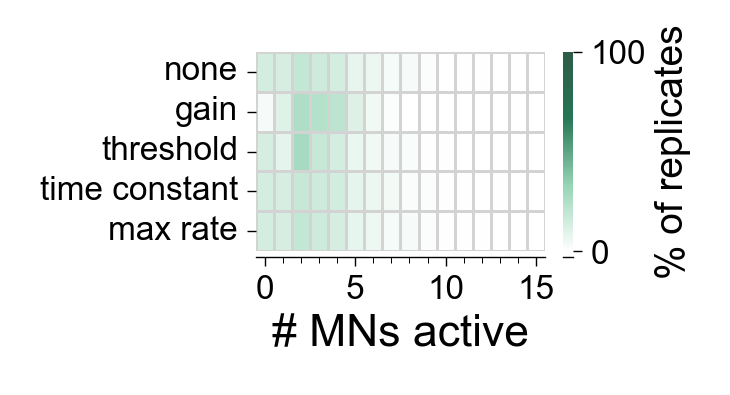

In [5]:
nMnsActiveCounts = nMnsActive_combined.apply(pd.Series.value_counts).fillna(0)
histBins = np.arange(200)
scoreHistDf = pd.DataFrame(index=histBins,columns = nMnsActive_combined.columns)
scoreHistDf.loc[nMnsActiveCounts.index] = nMnsActiveCounts
scoreHistDf.fillna(0,inplace=True)

scoreHistDf = scoreHistDf*100/nSims

xmax = 16
nBinsPlotted = len(scoreHistDf[:xmax])
xticklabels = np.round(histBins[np.arange(0,nBinsPlotted+1)],1).astype(str).tolist()
for i in range(len(xticklabels)):
    if i % 5 !=0:
        xticklabels[i]=""

plt.figure(figsize=(1.1647,0.648))

ax = sns.heatmap(scoreHistDf[:xmax].transpose(),cmap=make_palette(mnColor),cbar_kws={"ticks":[0,100]},cbar=True,vmin=0,vmax=100,yticklabels=True,linecolor="lightgray",linewidths=0.5)
cbar = ax.collections[0].colorbar
cbar.set_label("% of replicates",fontsize=7)
sns.despine(offset={"left":2,"bottom":1},left=True)

sns.despine(offset={"left":2,"bottom":1},left=True)


ax.set_xticks(np.arange(0.5,nBinsPlotted+.5,5),np.round(histBins[np.arange(0,nBinsPlotted+1,5)],1))
ax.set_xticks(np.arange(0.5,nBinsPlotted+.5,1),minor=True)

plt.gcf().set_dpi(400)
plt.xlabel("# MNs active")

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnStackedHeatmaps_xlim15.svg",transparent=True)

plt.show()

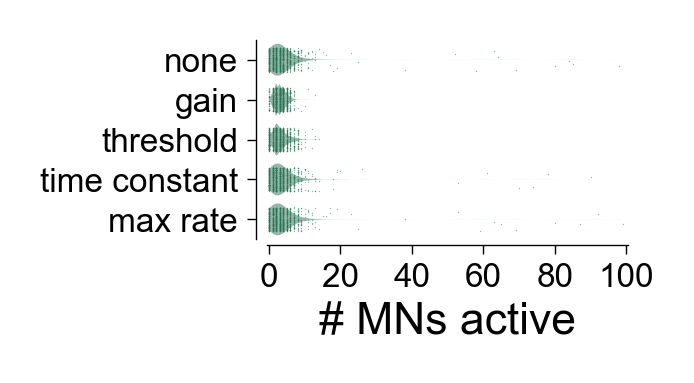

In [6]:
plt.figure(figsize=(1.1647,0.648))

sns.violinplot(nMnsActive_combined,color=mnColor,orient='h',edgecolor=None,inner=None,cut=0,alpha=0.5,density_norm="count")
sns.stripplot(nMnsActive_combined,color=mnColor,orient='h',edgecolor=None,alpha=0.5,size=.25,jitter=0.3)
sns.despine(offset={"left":2,"bottom":1})

plt.gcf().set_dpi(400)
plt.xlabel("# MNs active")
plt.xticks(np.arange(0,120,20))
plt.xlim([-0.5,100.5])

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnViolinPlot.svg",transparent=True)
plt.show()

# DN screen with 3x standard deviations of biophysical parameters

In [2]:
simType = "DN_Screen"
simPath = simType+"/hyak/run_id=32753379" 
folder = dataPath + simPath

params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))
wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1],index_col=0)
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
neuronParams = h5py.File(folder+"/ckpt/neuron_params.h5","r")

inputs = neuronParams["input_currents"][:]
nDns = inputs.shape[0]
nReps = inputs.shape[1]

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


## load data

### run the first time to load all outputs and save the summary

In [3]:
scores = np.zeros((nDns,nReps))
nActive = np.zeros((nDns,nReps))
# nMnsActive = np.zeros((nDns,nReps))
dnIdxList = []

finalResultsDir = folder + "/ckpt/checkpoints/results_final"
Rs_batch = sparse.load_npz(finalResultsDir+f"/Final_batch_Rs_0.npz").todense()
# print(f"Loaded batch 0, shape {Rs_batch.shape}.")
batchSize = len(Rs_batch)

for batch in tqdm(range(len(os.listdir(finalResultsDir)))):
    
    if batch !=0:
        Rs_batch = sparse.load_npz(finalResultsDir+f"/Final_batch_Rs_{batch}.npz").todense()
    print(f"Loaded batch {batch}, shape {Rs_batch.shape}.")
    
    for i in range(len(Rs_batch)):
        global_i = batch*batchSize + i
        nrnNo = global_i // nReps
        rep = global_i % nReps

        dnIdx = np.where(inputs[nrnNo].sum(0)>0)[0]
        if dnIdx not in dnIdxList:
            dnIdxList += dnIdx.tolist()

        R = Rs_batch[i]
        activeMask = np.max(R,1)>0.01
        nActive[nrnNo,rep] = np.sum(activeMask)
        # activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        # nMnsActive[nrnNo,rep] = np.sum(activeMnsMask)
        activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
        scores[nrnNo,rep] = score

  0%|          | 0/59 [00:00<?, ?it/s]

Loaded batch 0, shape (256, 4604, 1001).


  2%|▏         | 1/59 [00:12<12:30, 12.93s/it]

Loaded batch 1, shape (256, 4604, 1001).


  3%|▎         | 2/59 [00:25<11:51, 12.48s/it]

...

 97%|█████████▋| 57/59 [11:53<00:25, 12.71s/it]

Loaded batch 57, shape (256, 4604, 1001).


 98%|█████████▊| 58/59 [12:05<00:12, 12.53s/it]

Loaded batch 58, shape (80, 4604, 1001).


100%|██████████| 59/59 [12:09<00:00, 12.37s/it]


In [4]:
scoreSummary = pd.DataFrame(scores,index=dnIdxList)
activitySummary = pd.DataFrame(nActive,index=dnIdxList)

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# scoreSummary.to_csv(figFolder+"/scoreSummary.csv")
# activitySummary.to_csv(figFolder+"/activitySummary.csv")

### run if the summary is already created to load it

In [7]:
figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

scores = pd.read_csv(figFolder+"/scoreSummary.csv",index_col=0)
nActive = pd.read_csv(figFolder+"/activitySummary.csv",index_col=0)

dnIdxList = []
for i in range(len(scores)):
    dnIdxList += np.where(inputs[i].sum(0)>0)[0].tolist()

## plot results

In [8]:
usableScores = scores.copy()
usableScores[nActive<5]=np.nan
usableScores[nActive>1500]=np.nan
usableScoreSummary = pd.DataFrame(usableScores,index=dnIdxList)

usableScoreSummary["mean"] = usableScoreSummary.mean(1,skipna=True)
usableScoreSummary.insert(0,"bodyId",usableScoreSummary.index.map(dict(zip(wTable.index,wTable["bodyId"]))))

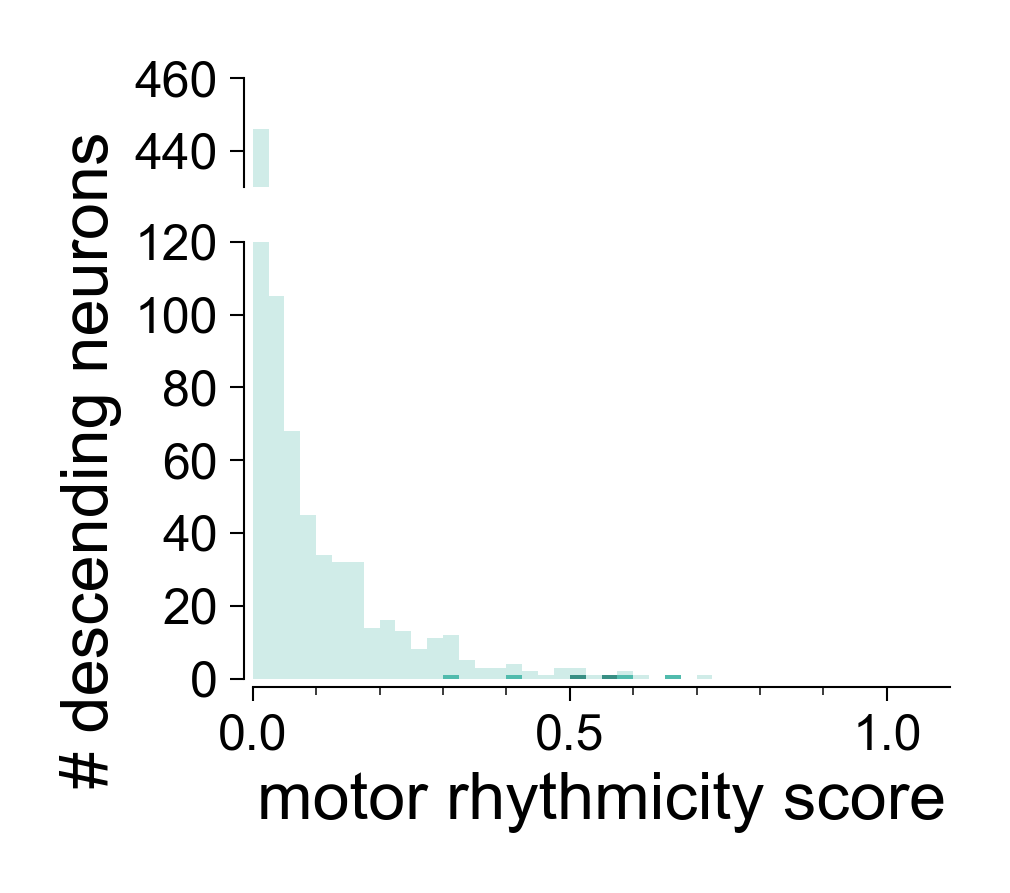

: 

In [ ]:
fig,ax = plt.subplots(2,1,height_ratios=[1,4])#,sharex=True)

sns.histplot(usableScoreSummary["mean"].dropna(),bins=np.arange(0,1.1,0.025),color="#d0ece8ff",edgecolor="None",ax=ax[1],alpha=1,zorder=-1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index.isin(wTable.loc[wTable["type"]=="DNb08"].index),"mean"],
             bins=np.arange(0,1.1,0.025),color="#51bbad",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
sns.histplot(usableScoreSummary.loc[usableScoreSummary.index.isin(wTable.loc[wTable["type"]=="DNg100"].index),"mean"],
             bins=np.arange(0,1.1,0.025),color="#388f84ff",edgecolor="None",ax=ax[1],alpha=1,zorder=1)
ax[1].set_ylabel("# descending neurons")
# ax[1].yaxis.set_label_position("top")
ax[1].set_xlabel("motor rhythmicity score")
ax[1].set_yticks(np.arange(0,1000,20))
ax[1].set_xticks(np.arange(0,1.1,0.5))
ax[1].set_xticks(np.arange(0,1.1,0.1),minor=True)
ax[1].set_xlim([0,1.1])
ax[1].set_ylim([0,120])
# ax[1].invert_xaxis()

sns.histplot(usableScoreSummary["mean"].dropna(),bins=np.arange(0,1.1,0.025),color="#d0ece8ff",edgecolor="None",ax=ax[0],alpha=1)
# ax[0].invert_xaxis()
ax[0].set_ylabel("")
ax[0].set_yticks(np.arange(0,1000,20))
ax[0].set_ylim([430,460])
ax[0].set_xlim([0,1.1])
ax[0].set_xticks([])
ax[0].set_xlabel("")

sns.despine(offset=1,ax=ax[1])#,top=False,bottom=True)
sns.despine(offset=1,ax=ax[0],bottom=True)#,top=False,bottom=True,left=True)
# ax[1].yaxis.tick_top()
# ax[0].yaxis.tick_top()

fig.set_dpi(600)

fig.set_figheight(1.3)
fig.set_figwidth(1.5)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/dnScoresHist_vertical.svg",transparent=True)
plt.show()

# DNg100 activation with no size information

In [2]:
simType = "DNg100_Stim"
simPath = simType+"/hyak/run_id=32928093"
folder = dataPath + simPath

print(Rs_npz_info(folder+f"/ckpt/{simType}_Rs.npz"))
Rs = load_Rs_npz(folder+f"/ckpt/{simType}_Rs.npz")
params = DictConfig(load_from_yaml(folder+"/logs/run_config.yaml"))

dataset = 0
nSims = Rs.shape[1]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive = pd.Series(index=np.arange(nSims))
nMnsActivePastTransient = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    # active neurons
    R = Rs[dataset,i].todense()
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    nMnsActivePastTransient.loc[i] = np.sum(activeMnsMaskPastTransient)
    simScore.loc[i] = score

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

{'shape': (1, 1024, 4604, 2001), 'nnz': 1284409575, 'nDims': 4, 'density': 0.13615110620036827, 'coordsInt64GB': 41.1011064, 'coordsInt32GB': 20.5505532, 'dataGB': 5.1376383, 'denseGB': 37.734825984, 'coordsDtype': dtype('int64'), 'dataDtype': dtype('float32')}


/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


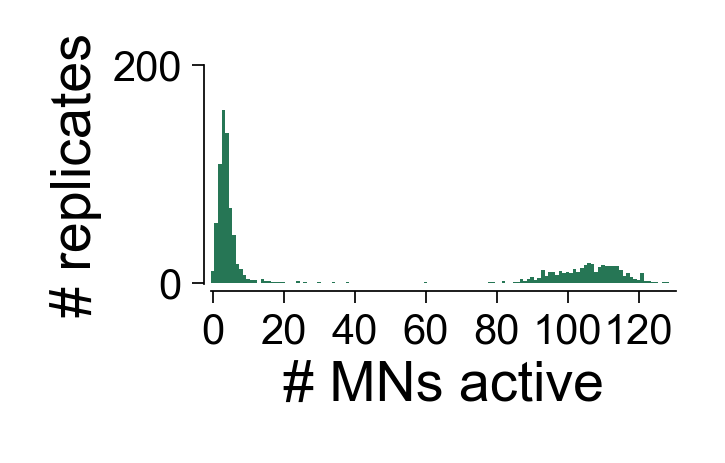

In [3]:
plt.figure(figsize=(1.200,0.57))

ax = sns.histplot(nMnsActive,color=mnColor,edgecolor="none",binwidth=1,kde=False,alpha=1,discrete=True)

plt.ylim([-1,200])
plt.xticks(np.arange(0,130,20))
plt.xlim([-0.5,130.5])
plt.ylabel("# replicates",fontsize=8)
plt.xlabel("# MNs active",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
sns.despine(offset=1)
plt.gcf().set_dpi(500)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnHistZoomedOut_2.svg",transparent=True)
plt.show()

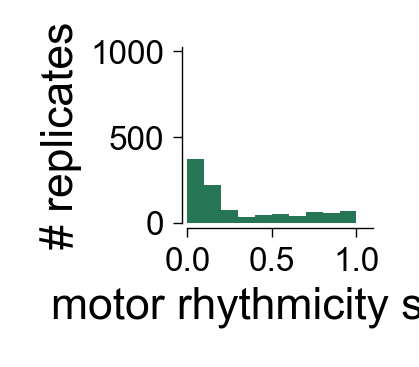

In [4]:
plt.figure(figsize=(0.600,0.57))

ax = sns.histplot(simScore,color=mnColor,edgecolor="none",bins=np.arange(0,1.5,0.10000001),kde=False,alpha=1.0)
plt.xlim([0,1.1])
plt.ylim([0,1024])
plt.yticks([0,500,1000])
plt.xticks(np.arange(0,1.1,0.5))
plt.xlabel("motor rhythmicity score",fontsize=8)
plt.ylabel("# replicates",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)

sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreHist.svg",transparent=True)
plt.show()

# Neurotransmitter $b$ parameter grid

In [2]:
simType = "DNg100_Stim"
simPath = simType+"/hyak/run_id=33258130"
folder = dataPath + simPath
overallParams = DictConfig(load_from_yaml(folder+"/multirun.yaml"))
wTable = pd.read_csv("../"+overallParams.experiment["dfPath"].split("vnc-connectome-sim")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


## load for the first time

This loading takes a long time and combines multiple runs to cover the full grid.

In [4]:
overrides = {}
for override in overallParams.hydra.overrides.task:
    p,v = override.split("=")
    overrides[p] = v

achBs = [float(i) for i in overrides["neuron_params.excitatoryMultiplier"].split(",")]
gabaBs = [float(i) for i in overrides["neuron_params.inhibitoryMultiplier"].split(",")]
gluBs = [float(i) for i in overrides["neuron_params.inhibitoryMultiplier"].split(",")]
bIdx = pd.MultiIndex.from_product([achBs,gabaBs,gluBs],names=["achB","gabaB","gluB"])

nSims = overallParams.experiment.n_replicates
nActive = pd.DataFrame(columns=bIdx,index=np.arange(nSims))
nMnsActive = pd.DataFrame(columns=bIdx,index=np.arange(nSims))
simScore = pd.DataFrame(columns=bIdx,index=np.arange(nSims))
mnFreq = pd.DataFrame(columns=bIdx,index=np.arange(nSims))

subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}"):
        subfolders.append(f)

for subfolder in tqdm(sorted(subfolders)):
    try: # some of them did not run/save properly the first time
        # Rs = sparse.load_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz").todense()
        Rs = load_Rs_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz")
    except: # IndexError:
        print(f"{subfolder} initial loading problems")
        continue
        # print(f"initial index error...")
        # try:
        #     tmp = sparse.load_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz")
        #     Rs = tmp.todense()
        # except:
        #     print(f"{subfolder} weird loading problems!!")
        #     continue
    dataset = 0
    # Rs = Rs[dataset]
    params = DictConfig(load_from_yaml(folder+f"/{subfolder}/.hydra/config.yaml"))
    achB = params.neuron_params.excitatoryMultiplier
    gabaB = params.neuron_params.inhibitoryMultiplier
    gluB = params.neuron_params.glutamateMultiplier
    for i in range(nSims):
        # active neurons
        try:
            R = Rs[dataset,i].todense()
        except:
            print(f"{subfolder} todense() problems")
            continue

        nActive.loc[i,(achB,gabaB,gluB)] = sum(np.max(R,1)>0.01)
        activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        nMnsActive.loc[i,(achB,gabaB,gluB)] = np.sum(activeMnsMask)
        activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        score, freq = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
        simScore.loc[i,(achB,gabaB,gluB)] = score
        mnFreq.loc[i,(achB,gabaB,gluB)] = freq

 86%|████████▋ | 101/117 [29:22<08:56, 33.55s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.01333,neuron_params.inhibitoryMultiplier=0.02 todense() problems


 88%|████████▊ | 103/117 [30:46<08:09, 35.00s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.01333,neuron_params.inhibitoryMultiplier=0.045 todense() problems


 90%|████████▉ | 105/117 [32:58<10:19, 51.60s/it]

...

 96%|█████████▌| 112/117 [39:39<04:53, 58.63s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.045,neuron_params.inhibitoryMultiplier=0.02 todense() problems


 97%|█████████▋| 114/117 [41:44<03:01, 60.44s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.0675,neuron_params.inhibitoryMultiplier=0.01333 todense() problems


100%|██████████| 117/117 [44:11<00:00, 22.66s/it]


In [15]:
rerunSimPath = simType+"/hyak/run_id=34251325"
rerunFolder = dataPath + rerunSimPath
rerunParams = DictConfig(load_from_yaml(rerunFolder+"/multirun.yaml"))

nSims = overallParams.experiment.n_replicates

rerunSubfolders = []
for f in os.listdir(rerunFolder):
    if os.path.isdir(f"{rerunFolder}/{f}"):
        rerunSubfolders.append(f)

for subrerunFolder in tqdm(sorted(rerunSubfolders)):
    # print(f"Loading {subrerunFolder}")
    try:
        # Rs = sparse.load_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz").todense()
        Rs = load_Rs_npz(folder+f"/{subrerunFolder}/ckpt/{simType}_Rs.npz")
    except: # IndexError:
        print(f"{subrerunFolder} initial loading problems")
        continue
    
    dataset = 0
    params = DictConfig(load_from_yaml(rerunFolder+f"/{subrerunFolder}/.hydra/config.yaml"))
    # achB = str(params.neuron_params.excitatoryMultiplier)
    # gabaB = str(params.neuron_params.inhibitoryMultiplier)
    # gluB = str(params.neuron_params.glutamateMultiplier)
    achB = params.neuron_params.excitatoryMultiplier
    gabaB = params.neuron_params.inhibitoryMultiplier
    gluB = params.neuron_params.glutamateMultiplier
    for i in range(nSims):
        # active neurons
        try:
            R = Rs[dataset,i].todense()
        except:
            print(f"{subrerunFolder} todense() problems")
            continue

        nActive.loc[i,(achB,gabaB,gluB)] = sum(np.max(R,1)>0.01)
        activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        nMnsActive.loc[i,(achB,gabaB,gluB)] = np.sum(activeMnsMask)
        activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        score, freq = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
        simScore.loc[i,(achB,gabaB,gluB)] = score
        mnFreq.loc[i,(achB,gabaB,gluB)] = freq


  0%|          | 0/15 [00:00<?, ?it/s]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.03,neuron_params.inhibitoryMultiplier=0.01333 todense() problems


 20%|██        | 3/15 [03:21<13:14, 66.22s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.03,neuron_params.inhibitoryMultiplier=0.045 initial loading problems
experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.03,neuron_params.inhibitoryMultiplier=0.0675 initial loading problems


 40%|████      | 6/15 [04:27<05:33, 37.01s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.045,neuron_params.inhibitoryMultiplier=0.02 todense() problems


 53%|█████▎    | 8/15 [06:31<05:33, 47.60s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.045,neuron_params.inhibitoryMultiplier=0.045 initial loading problems
experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.045,neuron_params.inhibitoryMultiplier=0.0675 initial loading problems


100%|██████████| 15/15 [08:54<00:00, 35.64s/it]

experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.0675,neuron_params.inhibitoryMultiplier=0.045 initial loading problems
experiment.seed=145,neuron_params.excitatoryMultiplier=0.0675,neuron_params.glutamateMultiplier=0.0675,neuron_params.inhibitoryMultiplier=0.0675 initial loading problems


In [18]:
otherRunIds = [34280323,34280329,34280336,34280337,34280345]

nSims = overallParams.experiment.n_replicates


for runId in tqdm(otherRunIds):
    print(f"Loading run {runId}")
    simPath = simType+f"/hyak/run_id={runId}"
    folder = dataPath + simPath

    try:
        Rs = load_Rs_npz(folder+f"/ckpt/{simType}_Rs.npz")
    except:
        print(f"{runId} initial loading problems")
        continue

    # try:
    #     Rs = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
    # except IndexError:
    #     print(f"initial index error...")
    #     try:
    #         tmp = sparse.load_npz(folder+f"/ckpt/{simType}_Rs.npz").todense()
    #         Rs = tmp.todense()
    #     except:
    #         print(f"{runId} weird loading problems!!")
    #         continue
    # except:
    #     print(f"{runId} weird loading problems!!")
    #     continue

    dataset = 0
    params = DictConfig(load_from_yaml(folder+f"/.hydra/config.yaml"))
    achB = params.neuron_params.excitatoryMultiplier
    gabaB = params.neuron_params.inhibitoryMultiplier
    gluB = params.neuron_params.glutamateMultiplier
    for i in range(nSims):
        # active neurons
        try:
            R = Rs[dataset,i].todense()
        except:
            print(f"{runId} todense() problems")
            continue

        nActive.loc[i,(achB,gabaB,gluB)] = sum(np.max(R,1)>0.01)
        activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        nMnsActive.loc[i,(achB,gabaB,gluB)] = np.sum(activeMnsMask)
        activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        score, freq = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
        simScore.loc[i,(achB,gabaB,gluB)] = score
        mnFreq.loc[i,(achB,gabaB,gluB)] = freq

  0%|          | 0/5 [00:00<?, ?it/s]

Loading run 34280323


 20%|██        | 1/5 [01:07<04:28, 67.18s/it]

Loading run 34280329


 40%|████      | 2/5 [02:01<02:59, 59.74s/it]

...

Loading run 34280337


 80%|████████  | 4/5 [03:56<00:57, 57.88s/it]

Loading run 34280345


100%|██████████| 5/5 [04:07<00:00, 49.54s/it]

34280345 initial loading problems


In [19]:
finalSimPath = simType+f"/default/run_id=hyak-33258130_finalRerun_20260402"
finalFolder = dataPath + finalSimPath

try:
    Rs = load_Rs_npz(finalFolder+f"/ckpt/{simType}_Rs.npz")
except:
    print(f"{runId} initial loading problems")

# try:
#     Rs = sparse.load_npz(finalFolder+f"/ckpt/{simType}_Rs.npz").todense()
# except IndexError:
#     print(f"initial index error...")
#     try:
#         tmp = sparse.load_npz(finalFolder+f"/ckpt/{simType}_Rs.npz")
#         Rs = tmp.todense()
#     except:
#         print(f"{runId} weird loading problems!!")
# except:
#     print(f"{runId} weird loading problems!!")

dataset = 0
params = DictConfig(load_from_yaml(finalFolder+f"/.hydra/config.yaml"))
achB = params.neuron_params.excitatoryMultiplier
gabaB = params.neuron_params.inhibitoryMultiplier
gluB = params.neuron_params.glutamateMultiplier
for i in range(nSims):
    # active neurons
    try:
        R = Rs[dataset,i].todense()
    except:
        print(f"{runId} todense() problems")
        continue

    nActive.loc[i,(achB,gabaB,gluB)] = sum(np.max(R,1)>0.01)
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i,(achB,gabaB,gluB)] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, freq = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
    simScore.loc[i,(achB,gabaB,gluB)] = score
    mnFreq.loc[i,(achB,gabaB,gluB)] = freq

In [28]:
if not os.path.exists(figFolder):
    os.makedirs(figFolder)
nActive.to_csv(figFolder+"/nActive_multiIndex_20260826.csv")    
nMnsActive.to_csv(figFolder+"/nMnsActive_multiIndex_20260826.csv")
simScore.to_csv(figFolder+"/scores_multiIndex_20260826.csv")
mnFreq.to_csv(figFolder+"/frequencies_multiIndex_20260826.csv")

## reload and plot

In [29]:
if not os.path.exists(figFolder):
    os.makedirs(figFolder)
nActive = pd.read_csv(figFolder+"/nActive_multiIndex_20260402.csv",index_col=0,header=[0,1,2])
nMnsActive = pd.read_csv(figFolder+"/nMnsActive_multiIndex_20260402.csv",index_col=0,header=[0,1,2])
simScore = pd.read_csv(figFolder+"/scores_multiIndex_20260402.csv",index_col=0,header=[0,1,2])
mnFreq = pd.read_csv(figFolder+"/frequencies_multiIndex_20260402.csv",index_col=0,header=[0,1,2])

In [30]:
achBs = simScore.columns.get_level_values("achB").unique()
gabaBs = simScore.columns.get_level_values("gabaB").unique()
gluBs = simScore.columns.get_level_values("gluB").unique()

In [31]:
meanScores = np.full((len(achBs),len(gabaBs),len(gluBs)),np.nan)

for i in range(len(achBs)):
    achB = achBs[i]
    for j in range(len(gabaBs)):
        gabaB = gabaBs[j]
        for k in range(len(gluBs)):
            gluB = gluBs[k]
            meanScores[i][j][k] = np.nanmean(simScore[(achB,gabaB,gluB)])

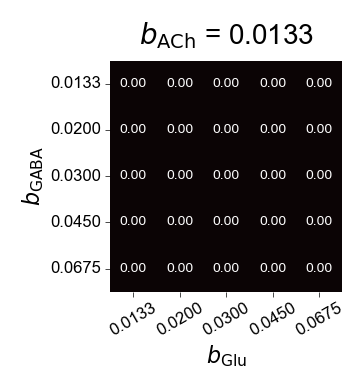

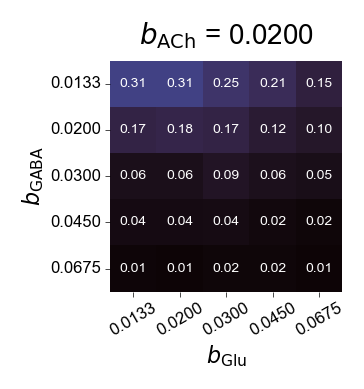

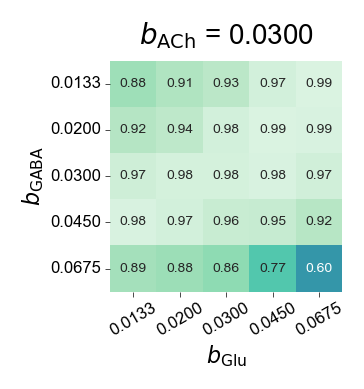

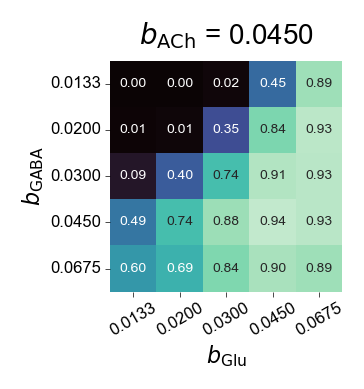

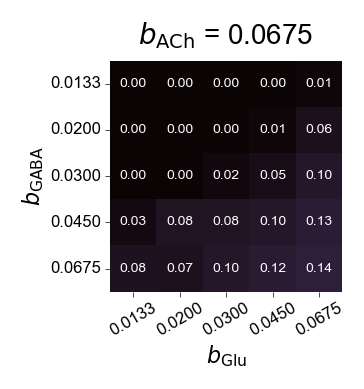

In [32]:
for i in range(len(achBs)):
    plt.figure(figsize=(1.5,1.5))
    sns.heatmap(meanScores[i],annot=True,vmin=0,vmax=1,xticklabels=[f"{b:.4f}" for b in gabaBs.astype(float)],yticklabels=[f"{b:.4f}" for b in gluBs.astype(float)],cbar=False,cmap="mako",
                fmt=".2f",annot_kws={'fontsize':5})
    plt.xticks(rotation=30)
    plt.title(r"$b_\text{ACh}$ = "+f"{float(achBs[i]):.4f}")
    plt.ylabel(r"$b_\text{GABA}$")
    plt.xlabel(r"$b_\text{Glu}$")

    # if not os.path.exists(figFolder):
    #     os.makedirs(figFolder)
    # plt.savefig(figFolder+f"/bGridMeanScores_20260402_achB_{achBs[i]}.svg",transparent=True)
    
    plt.show()

In [33]:
meanMnsActive = np.full((len(achBs),len(gabaBs),len(gluBs)),np.nan)

for i in range(len(achBs)):
    achB = achBs[i]
    for j in range(len(gabaBs)):
        gabaB = gabaBs[j]
        for k in range(len(gluBs)):
            gluB = gluBs[k]
            meanMnsActive[i][j][k] = np.mean(nMnsActive[(achB,gabaB,gluB)])

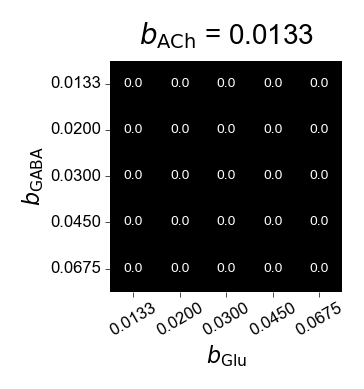

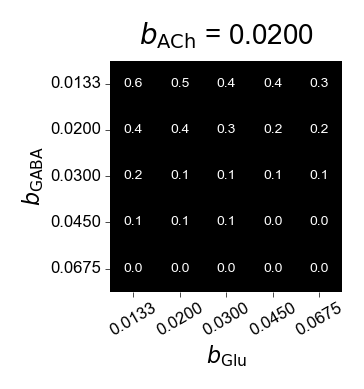

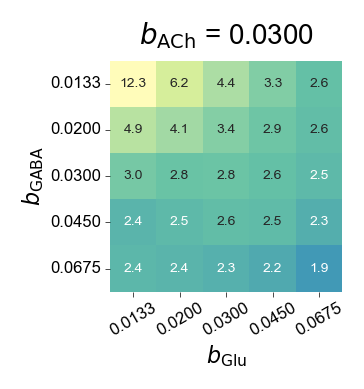

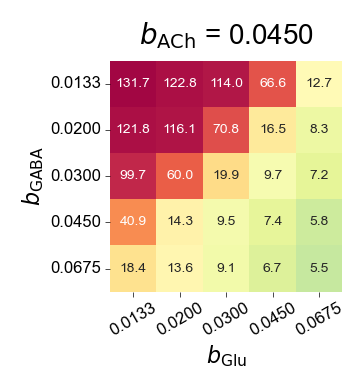

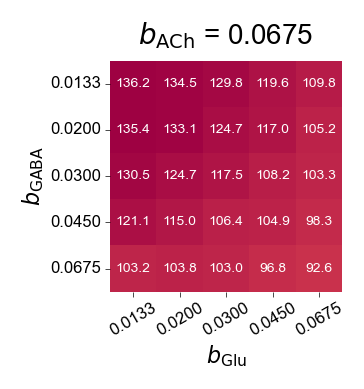

In [34]:
activeNorm = colors.LogNorm(vmin=1, vmax=138)
activeCmap = sns.color_palette("Spectral_r", as_cmap=True).copy()
activeCmap.set_under('k')
activeCmap.set_bad('k')

for i in range(len(achBs)):
    plt.figure(figsize=(1.5,1.5))
    sns.heatmap(meanMnsActive[i],annot=True,xticklabels=[f"{b:.4f}" for b in gabaBs.astype(float)],norm=activeNorm,
                yticklabels=[f"{b:.4f}" for b in gluBs.astype(float)],cbar=False,cmap=activeCmap,
                fmt=".1f",annot_kws={'fontsize':5})
    plt.xticks(rotation=30)
    plt.title(r"$b_\text{ACh}$ = "+f"{float(achBs[i]):.4f}")
    plt.ylabel(r"$b_\text{GABA}$")
    plt.xlabel(r"$b_\text{Glu}$")

    # if not os.path.exists(figFolder):
    #     os.makedirs(figFolder)
    # plt.savefig(figFolder+f"/bGridMeanMnsActive_20260402_achB_{achBs[i]}.svg",transparent=True)
    
    plt.show()